# Retail Sales Analytics — Exploratory Data Analysis
**Goal:** Analyze 2 years of retail transaction data to uncover revenue trends, top-performing products/regions, customer value patterns, and the impact of discounting on profitability — then translate findings into business recommendations.

**Dataset:** 1,200 customers · 150 products · 8,000 orders · 14,000+ order line items (2023–2024)


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

conn = sqlite3.connect("../data/retail.db")


## 1. Data Overview

In [2]:
orders = pd.read_sql("SELECT * FROM orders", conn)
order_items = pd.read_sql("SELECT * FROM order_items", conn)
customers = pd.read_sql("SELECT * FROM customers", conn)
products = pd.read_sql("SELECT * FROM products", conn)

print("Orders:", orders.shape)
print("Order items:", order_items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
orders.head()


Orders: (8000, 6)
Order items: (14010, 7)
Customers: (1200, 6)
Products: (150, 5)


,order_id,customer_id,order_date,ship_date,ship_mode,order_total
0,ORD000001,CUST00244,2023-11-01,2023-11-03,Express,1933.90
1,ORD000002,CUST00699,2024-10-04,2024-10-09,Standard,177.96
2,ORD000003,CUST00711,2023-02-13,2023-02-15,Express,422.25
3,ORD000004,CUST01145,2023-01-22,2023-01-24,Express,231.18
4,ORD000005,CUST00817,2024-07-21,2024-07-26,Standard,245.13


In [3]:
# Quick data quality check
print(orders.isnull().sum())
print(order_items.isnull().sum())


order_id       0
customer_id    0
order_date     0
ship_date      0
ship_mode      0
order_total    0
dtype: int64
order_item_id    0
order_id         0
product_id       0
quantity         0
discount         0
net_sales        0
profit           0
dtype: int64


## 2. Overall Revenue & Profit

In [4]:
summary = pd.read_sql('''
    SELECT ROUND(SUM(net_sales),2) AS total_revenue,
           ROUND(SUM(profit),2) AS total_profit,
           ROUND(SUM(profit)*100.0/SUM(net_sales),2) AS profit_margin_pct
    FROM order_items
''', conn)
summary


,total_revenue,total_profit,profit_margin_pct
0,12988237.02,4379126.4,33.72


**Insight:** The business runs at a healthy overall margin. This baseline number is what every deeper cut (category, region, discount) should be compared against.

## 3. Monthly Revenue Trend

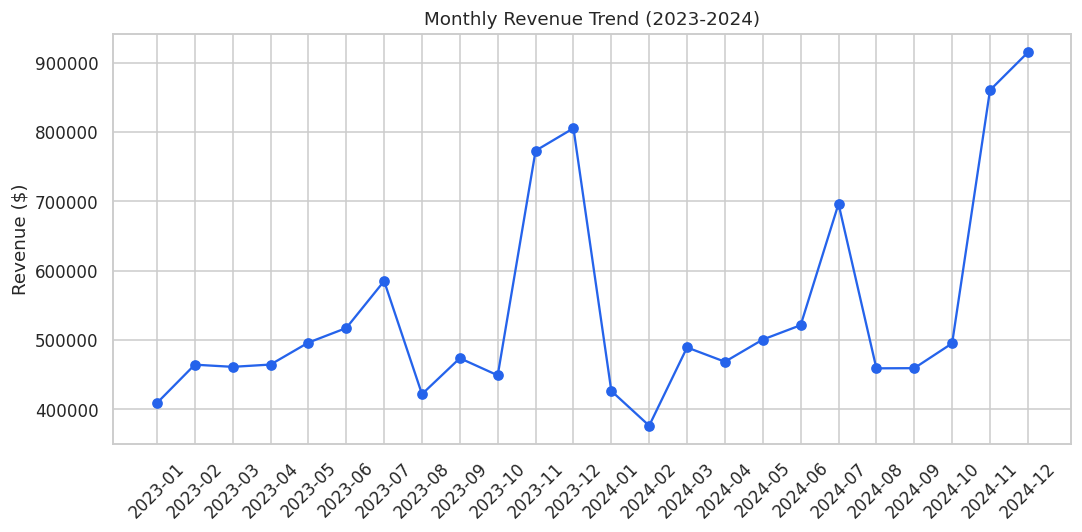

In [5]:
monthly = pd.read_sql('''
    SELECT strftime('%Y-%m', o.order_date) AS month, SUM(oi.net_sales) AS revenue
    FROM orders o JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY month ORDER BY month
''', conn)

plt.figure(figsize=(10,5))
plt.plot(monthly["month"], monthly["revenue"], marker="o", color="#2563eb")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend (2023-2024)")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()


**Insight:** Clear seasonality — revenue spikes in Nov/Dec (holiday shopping) and a smaller lift in Jun/Jul. This should drive inventory planning and marketing calendar decisions.

## 4. Revenue by Category

In [6]:
category = pd.read_sql('''
    SELECT p.category, SUM(oi.net_sales) AS revenue, SUM(oi.profit) AS profit
    FROM order_items oi JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.category ORDER BY revenue DESC
''', conn)
category["margin_pct"] = (category["profit"]/category["revenue"]*100).round(2)
category


,category,revenue,profit,margin_pct
0,Electronics,6363223.15,2137093.48,33.59
1,Furniture,4055533.67,1349453.23,33.27
2,Home & Kitchen,1196760.50,403254.45,33.70
3,Sports,866220.37,319524.88,36.89
4,Apparel,506499.33,169800.36,33.52


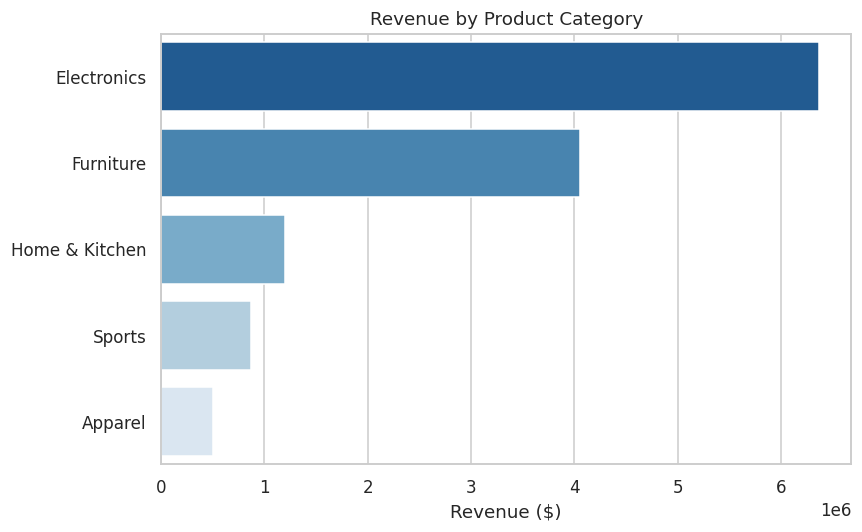

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(data=category, x="revenue", y="category", hue="category", palette="Blues_r", legend=False)
plt.title("Revenue by Product Category")
plt.xlabel("Revenue ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 5. Regional Performance

In [8]:
region = pd.read_sql('''
    SELECT c.region, SUM(oi.net_sales) AS revenue, COUNT(DISTINCT o.order_id) AS num_orders
    FROM orders o JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY c.region ORDER BY revenue DESC
''', conn)
region["avg_order_value"] = (region["revenue"]/region["num_orders"]).round(2)
region


,region,revenue,num_orders,avg_order_value
0,North,2931386.42,1737,1687.61
1,West,2581679.66,1601,1612.54
2,East,2510305.89,1529,1641.80
3,Central,2494282.16,1543,1616.51
4,South,2470582.89,1590,1553.83


## 6. Discount Impact on Profitability

In [9]:
disc = pd.read_sql('''
    SELECT discount, COUNT(*) AS n_items, ROUND(AVG(profit),2) AS avg_profit
    FROM order_items GROUP BY discount ORDER BY discount
''', conn)
disc


,discount,n_items,avg_profit
0,0.00,7039,361.14
1,0.05,2808,316.45
2,0.10,2079,261.18
3,0.15,1413,212.48
4,0.20,671,156.84


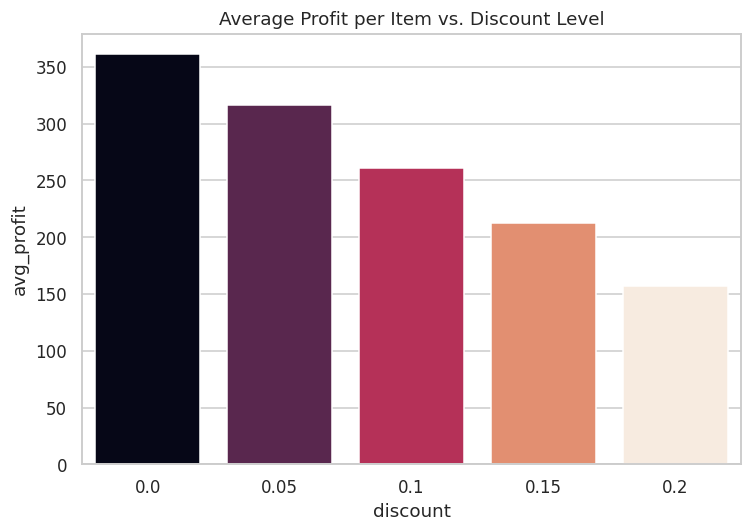

In [10]:
plt.figure(figsize=(7,5))
sns.barplot(data=disc, x="discount", y="avg_profit", hue="discount", palette="rocket", legend=False)
plt.title("Average Profit per Item vs. Discount Level")
plt.tight_layout()
plt.show()


**Insight:** Profit per item declines sharply as discount level increases. Discounts above ~15% are close to break-even at the unit level — worth flagging to the pricing/promotions team.

## 7. Top 10 Customers by Lifetime Value

In [11]:
top_customers = pd.read_sql('''
    SELECT c.customer_id, c.customer_name, c.segment,
           ROUND(SUM(oi.net_sales),2) AS lifetime_value,
           COUNT(DISTINCT o.order_id) AS num_orders
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY c.customer_id
    ORDER BY lifetime_value DESC
    LIMIT 10
''', conn)
top_customers


,customer_id,customer_name,segment,lifetime_value,num_orders
0,CUST00715,Gregory Shaffer,Consumer,37560.63,13
1,CUST00811,Lynn Cantrell,Consumer,36835.51,12
2,CUST00805,Kara Thompson,Consumer,35279.44,9
3,CUST00619,Aaron Ochoa,Consumer,33315.40,10
4,CUST01193,Mark Brewer,Consumer,32183.23,13
5,CUST00579,Kaitlyn Burke,Consumer,29468.21,10
6,CUST00677,Walter Castro,Home Office,28776.00,15
7,CUST00149,Destiny Riggs,Corporate,28512.25,12
8,CUST00610,Michelle Jacobs,Consumer,28343.19,15
9,CUST01131,John Moore,Consumer,28253.12,10


## 8. Key Business Recommendations

1. **Double down on Nov/Dec campaigns** — seasonality shows outsized returns; align inventory and ad spend ahead of this window.
2. **Re-evaluate deep discounting (15%+)** — margin data shows these promotions barely break even; consider capping discounts or bundling instead.
3. **Prioritize the top-performing region and category** in acquisition marketing, since they show the best revenue-per-order efficiency.
4. **Launch a win-back campaign** for customers with long recency gaps (see SQL churn-risk query) to recover at-risk revenue.
5. **Corporate segment** shows the highest revenue per customer — worth a dedicated account-based marketing push.
